In [2]:
from astropy.io import fits
import astropy.units as u
import numpy as np
import cmasher as cmr
import matplotlib.pyplot as plt

### Header definitions:

| Keyword  | Units  | Explanation                                                   |
| -------- | ------ | ------------------------------------------------------------- |
| SIMPLE   |        | Indicates that it is standard FITS file.                      |
| BITPIX   |        | Data type of pixel values.                                    |
| NAXIS    |        | Dimensions of file.                                           |
| NAXIS1   | pixels | Number of pixels along the first axis (RA).                   |
| NAXIS2   | pixels | Number of pixels along the second axis (Dec).                 |
| NAXIS3   | pixels | Number of pixels along the third axis (frequency).            |
| NAXIS4   | pixels | Number of pixels along the fourth axis (Stokes/polarization). |
| EXTEND   |        | Indicates that the file may contain extensions.               |
| BSCALE   |        | Linear scaling factor applied to pixel values.                |
| BZERO    |        | Offset applied to pixel values in conjuction with BSCALE      |
| BMAJ     | deg    | Major axis of the beam.                                       |
| BMIN     | deg    | Minor axis of the beam.                                       |
| BPA      | deg    | Position angle of the beam (east of north).                   |
| BTYPE    |        | Type of data contained in pixels.                             |
| BUNIT    |        | Units of pixel values                                         |
| OBJECT   |        | Name of observed target.                                      |
| TELESCOP |        | Telescope used.                                               |
| INSTRUME |        | Instrument used.                                              |
| OBSERVER |        | Name of the observer.                                         |
| DATE-OBS |        | Date and time of observation.                                 |
| DISTANCE | pc     | Distance to the source.                                       |
| FIELD    |        | Observing field (for example, target name or region of sky).  |
| INTENT   |        | Purpose of observation                                        |
| RADESYS  |        | Reference coordinate system.                                  |
| LONPOLE  | deg    | Longitude of celestial pole.                                  |
| LATPOLE  | deg    | Latitude of celestial pole.                                   |
| PCi_j    |        | Matrix elements used to map pixels to physical coordinates.   |
| CTYPE1   |        | Coordinate type of first axis (RA projection).                |
| CTYPE2   |        | Coordinate type of second axis (Dec projection).              |
| CRVAL1   | deg    | Coordinate value at reference pixel for first axis.           |
| CRVAL2   | deg    | Coordinate value at reference pixel for second axis.          |
| CDELT1   | deg    | Pixel scale along first axis.                                 |
| CDELT2   | deg    | Pixel scale along second axis.                                |
| CRPIX1   | pixels | Reference pixel along first axis.                             |
| CRPIX2   | pixels | Reference pixel along second axis.                            |
| CUNIT1   | deg    | Units for first axis (RA).                                    |
| CUNIT2   | deg    | Units for second axis (Dec).                                  |
| CTYPE3   |        | Type of third axis (frequency).                               |
| CRVAL3   | Hz     | Coordinate value at reference pixel for third axis.           |
| CDELT3   | Hz     | Pixel scale along third axis.                                 |
| CRPIX3   | pixels | Reference pixel along third axis.                             |
| CUNIT3   | Hz     | Units for third axis (frequency).                             |
| RESTFRQ  | Hz     | Rest frequency of observed line.                              |
| SPECSYS  |        | Spectral reference frame.                                     |
| VELREF   |        | Velocity reference value.                                     |
| CTYPE4   |        | Type of fourth axis (Stokes/polarization).                    |
| CRVAL4   |        | Coordinate value at reference pixel for fourth axis.          |
| CDELT4   |        | Spacing between Stokes parameters.                            |
| CRPIX4   | pixels | Reference pixel along fourth axis.                            |
| CUNIT4   |        | Units for fourth axis                                         |
| ALTRVAL  | Hz     | Alternate reference value.                                    |
| ALTRPIX  | pixels | Pixel for alternate frequency reference.                      |
| SPECMODE |        | Data formatting.                                              |
| SPW      |        | Spectral window number.                                       |
| TYPE     |        | Image type.                                                   |
| DATE     |        | Date of file creation.                                        |
| ORIGIN   |        | File software.                                                |



### Opening FITS file and defining important variables:

In [3]:
object = fits.open('HD163296_cube.fits')
object.info()

vslr = 5.8  # km/s

fulldata = object[0].data  # accessing data from primary HDU
imdata = np.squeeze(fulldata[0].data)  # load image data into extra axis; intensity in Jy/beam and frequency in Hz

hdr = object[0].header  # accessing header from primary HDU
restfrq = hdr['RESTFRQ']   # Hz
beam_pa = hdr['BPA']  # degrees
theta_maj = (hdr['BMAJ'] * u.deg).to(u.arcsec) # arcsec
theta_min = (hdr['BMIN'] * u.deg).to(u.arcsec) # arcsec
pix_size = (hdr['CDELT1'] * u.deg).to(u.arcsec)  # arcsec
nchan = imdata.shape[0] # number of channels
start_frequency = hdr['CRVAL3'] # Hz
channel_width = hdr['CDELT3'] # Hz
rest_frequency = hdr['RESTFRQ'] # Hz


Filename: HD163296_cube.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      92   (560, 560, 478, 1)   float32   


### Defining channel of source velocity rest emission and plotting channel map in arcseconds:

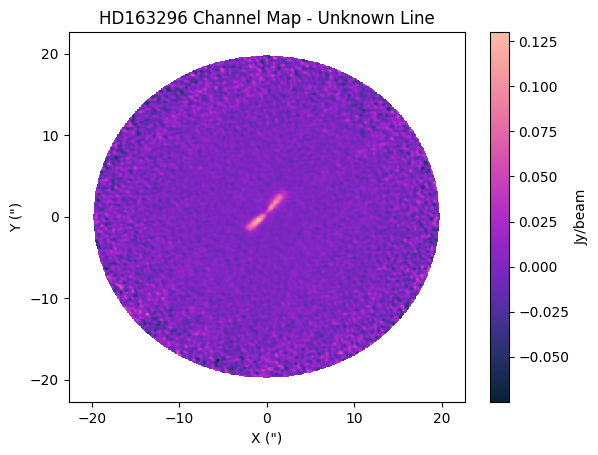

In [8]:
xoffs = hdr['CRVAL1'] + np.array([nn*hdr['CDELT1'] for nn in range(hdr['NAXIS1'])])
yoffs = hdr['CRVAL2'] + np.array([nn*hdr['CDELT2'] for nn in range(hdr['NAXIS2'])])

xvals = np.array(xoffs - xoffs[int(hdr['NAXIS1']/2)]) * u.deg.to(u.arcsec)
yvals = np.array(yoffs - yoffs[int(hdr['NAXIS2']/2)]) * u.deg.to(u.arcsec)


target_rest_freq = restfrq # Hz
target_freq = target_rest_freq * (1 - vslr/3e5) 
channel = int(round((target_freq - start_frequency)/channel_width))

image = plt.pcolormesh(xvals, yvals, imdata[channel,:, :], cmap='cmr.bubblegum')
plt.colorbar(label=hdr.get('BUNIT', 'Jy/beam'))
plt.title(f"{hdr.get('OBJECT', 'Unknown Object')} Channel Map - {hdr.get('LINE', 'Unknown Line')}")
plt.xlabel('X (")')
plt.ylabel('Y (")')
plt.show()


### Plotting moment0 map:

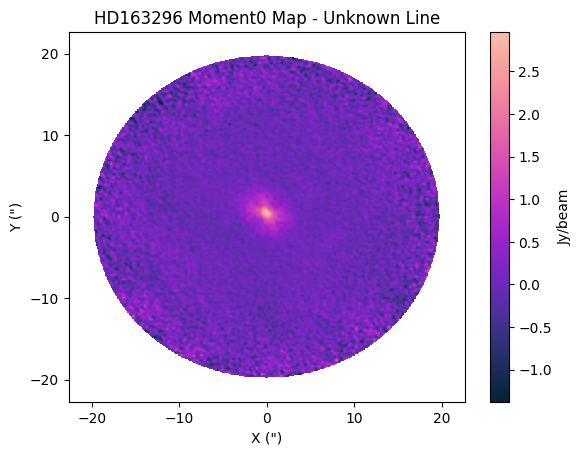

In [5]:
moment0 = np.sum(imdata, axis=0) 
image = plt.pcolormesh(xvals, yvals, moment0, cmap='cmr.bubblegum')
plt.colorbar(label=hdr.get('BUNIT', 'Jy/beam'))
plt.title(f"{hdr.get('OBJECT', 'Unknown Object')} Moment0 Map - {hdr.get('LINE', 'Unknown Line')}")
plt.xlabel('X (")')
plt.ylabel('Y (")')
plt.show()

### Plotting spectrum in terms of veloicty, centered on source velocity rest emission

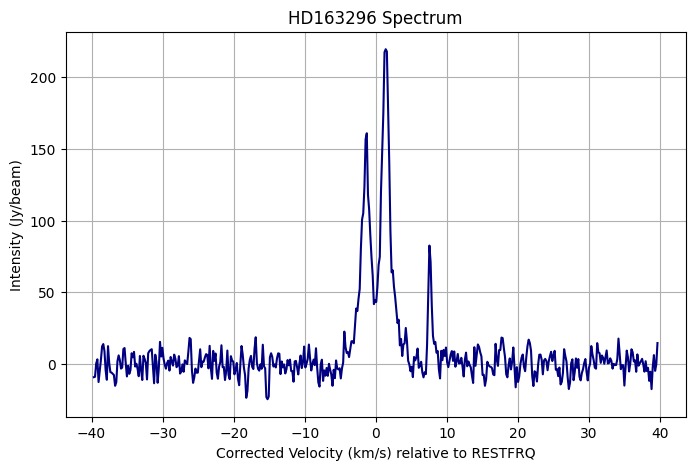

In [6]:
frequencies = start_frequency + channel_width * np.arange(nchan)  # Hz
velocities = ((rest_frequency - frequencies)/rest_frequency * 3e5)  # km/s
velocities_corr = velocities - vslr

spectrum = np.nansum(imdata, axis=(1,2))  # Jy/beam

plt.figure(figsize=(8,5))
plt.plot(velocities_corr, spectrum, color='navy')
plt.xlabel("Corrected Velocity (km/s) relative to RESTFRQ")
plt.ylabel(f"Intensity ({hdr.get('BUNIT','Unknown Unit')})")
plt.title(f"{hdr.get('OBJECT','Unknown Object')} Spectrum")
plt.grid(True)
plt.show()
